He tenido que poner a 1 las variables de entorno de abajo porque en un modelo no paramétrico me saltaban errores por algún tema de hilos

In [7]:
import os
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['NUMEXPR_NUM_THREADS'] = '1'

In [8]:
import kagglehub

path = kagglehub.dataset_download("ninadaithal/imagesoasis")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/imagesoasis


In [9]:
import os
dataset_path = path + '/Data'

non_demented_path = os.path.join(dataset_path, 'Non Demented')
moderate_demented_path = os.path.join(dataset_path, 'Moderate Dementia')
mild_demented_path = os.path.join(dataset_path, 'Mild Dementia')
very_mild_demented_path = os.path.join(dataset_path, 'Very mild Dementia')

non_demented_images = [os.path.join(non_demented_path, file) for file in os.listdir(non_demented_path) if file.endswith('.jpg')]
moderate_demented_images = [os.path.join(moderate_demented_path, file) for file in os.listdir(moderate_demented_path) if file.endswith('.jpg')]
mild_demented_images = [os.path.join(mild_demented_path, file) for file in os.listdir(mild_demented_path) if file.endswith('.jpg')]
very_mild_demented_images = [os.path.join(very_mild_demented_path, file) for file in os.listdir(very_mild_demented_path) if file.endswith('.jpg')]

from sklearn.model_selection import train_test_split
non_demented_train, non_demented_test = train_test_split(non_demented_images, test_size=0.2, random_state=42)
moderate_demented_train, moderate_demented_test = train_test_split(moderate_demented_images, test_size=0.2, random_state=42)
mild_demented_train, mild_demented_test = train_test_split(mild_demented_images, test_size=0.2, random_state=42)
very_mild_demented_train, very_mild_demented_test = train_test_split(very_mild_demented_images, test_size=0.2, random_state=42)

print(len(non_demented_train), len(moderate_demented_train), len(mild_demented_train), len(very_mild_demented_train))

import random
target_samples = 3000

moderate_demented_sample = random.choices(moderate_demented_train, k=target_samples)
mild_demented_sample = random.choices(mild_demented_train, k=target_samples)

very_mild_demented_sample = random.sample(very_mild_demented_train, target_samples)
non_demented_sample = random.sample(non_demented_train, target_samples)

print(len(non_demented_test), len(moderate_demented_test), len(mild_demented_test), len(very_mild_demented_test))

target_samples = 640
mild_demented_test = random.sample(mild_demented_test, target_samples)
non_demented_test = random.sample(non_demented_test, target_samples)
very_mild_demented_test = random.sample(very_mild_demented_test, target_samples)


53777 390 4001 10980
13445 98 1001 2745


In [10]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder()
encoder.fit([[0], [1], [2], [3]])

from PIL import Image
import numpy as np
data = []
result = []

for image in non_demented_sample:
    img = Image.open(image)
    img = img.resize((128, 128))
    img = np.array(img)
    if img.shape == (128, 128, 3):
        data.append(img)
        result.append(0)

print("End 1")

for image in moderate_demented_sample:
    img = Image.open(image)
    img = img.resize((128, 128))
    img = np.array(img)
    if img.shape == (128, 128, 3):
        data.append(img)
        result.append(1)

print("End 2")

for image in mild_demented_sample:
    img = Image.open(image)
    img = img.resize((128, 128))
    img = np.array(img)
    if img.shape == (128, 128, 3):
        data.append(img)
        result.append(2)

print("End 3")

for image in very_mild_demented_sample:
    img = Image.open(image)
    img = img.resize((128, 128))
    img = np.array(img)
    if img.shape == (128, 128, 3):
        data.append(img)
        result.append(3)

print("End 4")

data = np.array(data, dtype='float32') / 255.0

data.shape

result = np.array(result)
result = np.array(result, dtype='float32')

X_train, x_val, y_train, y_val = train_test_split(data, result, test_size=0.2, random_state=42)


End 1
End 2
End 3
End 4


In [11]:
data_test = []
result_test = []

for image in non_demented_test:
    img = Image.open(image)
    img = img.resize((128, 128))
    img = np.array(img)
    if img.shape == (128, 128, 3):
        data_test.append(img)
        result_test.append(0)

print("End 1")

for image in moderate_demented_test:
    img = Image.open(image)
    img = img.resize((128, 128))
    img = np.array(img)
    if img.shape == (128, 128, 3):
        data_test.append(img)
        result_test.append(1)

print("End 2")

for image in mild_demented_test:
    img = Image.open(image)
    img = img.resize((128, 128))
    img = np.array(img)
    if img.shape == (128, 128, 3):
        data_test.append(img)
        result_test.append(2)

print("End 3")

for image in very_mild_demented_test:
    img = Image.open(image)
    img = img.resize((128, 128))
    img = np.array(img)
    if img.shape == (128, 128, 3):
        data_test.append(img)
        result_test.append(3)

print("End 4")

data_test = np.array(data_test, dtype='float32')/255

data_test.shape

result_test = np.array(result_test, dtype='float32')

X_test = data_test
y_test = result_test


End 1
End 2
End 3
End 4


# KNN
Para probar KNN se han definido diferentes valores de K y se han probado para ver cual daba mejores resultados. El modelo KNN predice a que clase pertenece un dato de acuerdo a la clase de sus K vecinos más cercanos.

In [30]:
ks = [3, 4, 5, 6, 7, 8, 9, 10]
acc_ks = []

In [31]:
from sklearn.neighbors import KNeighborsClassifier
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

for k in ks:
    model_knn = KNeighborsClassifier(n_neighbors=k)
    model_knn.fit(X_train_flat, y_train)
    acc = model_knn.score(X_test_flat, y_test)
    acc_ks.append(acc)
    print(f"Accuracy del modelo KNN-{k}: {acc*100:.2f}%")

Accuracy del modelo KNN-3: 97.42%
Accuracy del modelo KNN-4: 97.37%
Accuracy del modelo KNN-5: 95.99%
Accuracy del modelo KNN-6: 95.94%
Accuracy del modelo KNN-7: 95.19%
Accuracy del modelo KNN-8: 95.09%
Accuracy del modelo KNN-9: 94.60%
Accuracy del modelo KNN-10: 94.25%


El mejor resultado se ha dado cuando K = 3 obteniendo una precisión del 97.42%

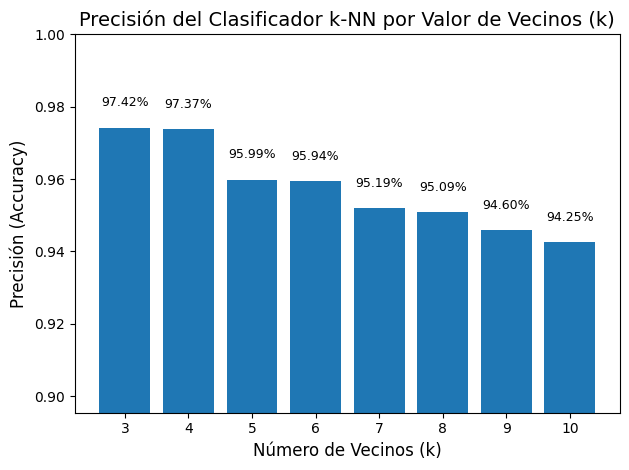

In [32]:
import matplotlib.pyplot as plt
bars = plt.bar(ks,acc_ks,width=0.8)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.005, 
             f'{yval*100:.2f}%', ha='center', va='bottom', fontsize=9)

plt.title('Precisión del Clasificador k-NN por Valor de Vecinos (k)', fontsize=14)
plt.xlabel('Número de Vecinos (k)', fontsize=12)
plt.ylabel('Precisión (Accuracy)', fontsize=12)

plt.xticks(ks) 

plt.ylim(min(acc_ks) * 0.95, 1) 

plt.tight_layout()

plt.show()

In [33]:
from sklearn.metrics import f1_score, confusion_matrix

best_k_index = np.argmax(acc_ks)
best_k = ks[best_k_index]
model_knn = KNeighborsClassifier(n_neighbors=best_k)
model_knn.fit(X_train_flat, y_train)
acc = model_knn.score(X_test_flat, y_test)
f1 = f1_score(y_test, model_knn.predict(X_test_flat), average='weighted')
c_matrix = confusion_matrix(y_test, model_knn.predict(X_test_flat))

In [34]:
print(f1)
print(c_matrix)

0.9739748608021083
[[589   3  14  34]
 [  0  98   0   0]
 [  0   0 640   0]
 [  1   0   0 639]]


# RandomForestClassifier

Para probar este modelo se han utilizado diferentes cantidades de árboles. Por cada árbol del modelo se realiza una decisión a partir de los datos de entrada. Cada árbol predice una clase y se selecciona la clase predicha a partir de la predicciones de todos los árboles obteniendo la mayoría.

In [7]:
from sklearn.ensemble import RandomForestClassifier; from sklearn.metrics import accuracy_score

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

accuracies = []
n_trees = [10, 100, 1000]
for ntree in n_trees:
    clf = RandomForestClassifier(n_estimators=ntree, random_state=10).fit(X_train_flat, y_train)
    y_predicted = clf.predict(X_test_flat)
    acc = accuracy_score(y_test, y_predicted)
    accuracies.append(acc)
    print(f'RF {ntree} trees: {acc:.1%}, test err {1 - acc:.1%}')

RF 10 trees: 88.9%, test err 11.1%
RF 100 trees: 97.0%, test err 3.0%
RF 1000 trees: 97.7%, test err 2.3%


El mejor resultado obtenido ha sido con 1000 arboles obteniendo un 97.7% de precisión

In [10]:
from sklearn.metrics import f1_score, confusion_matrix

best_ntree = n_trees[np.argmax(accuracies)]
clf = RandomForestClassifier(n_estimators=best_ntree, random_state=10).fit(X_train_flat, y_train)
y_predicted = clf.predict(X_test_flat)
acc = accuracy_score(y_test, y_predicted)
f1 = f1_score(y_test, clf.predict(X_test_flat), average='weighted')
c_matrix = confusion_matrix(y_test, clf.predict(X_test_flat))

In [11]:
print(acc)
print(f1)
print(c_matrix)

0.9767096134786918
0.9766545799908761
[[600   0   5  35]
 [  0  98   0   0]
 [  1   0 637   2]
 [  4   0   0 636]]


# DecisionTreeClassifier
Para este modelo se han estudiado diferentes profundidades yendo de la 2 hasta la 30. En cada árbol se dividen los datos en dos subconjuntos dependiendo de una categoría de los datos. Esta división se va aplicando recursivamente hasta llegar a la profundidad especificada, hasta que todos los ejemplos de un nodo pertenezcan a la misma clase o haya muy pocos ejemplos para dividir.

In [15]:
accuracies_dt = []
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier; from sklearn.metrics import accuracy_score

depths = [2, 4, 6, 8, 10, 12, 15, 20, 25, 30]

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

for depth in depths:
    clf = DecisionTreeClassifier(
        criterion="entropy", 
        random_state=10, 
        max_depth=depth
    ).fit(X_train_flat, y_train)
    
    y_predicted = clf.predict(X_test_flat)
    acc = accuracy_score(y_test, y_predicted)
    accuracies_dt.append(acc)
    print(f'Decision Tree max_depth={depth}: {acc:.1%}, test err {1 - acc:.1%}')

Decision Tree max_depth=2: 30.0%, test err 70.0%
Decision Tree max_depth=4: 46.6%, test err 53.4%
Decision Tree max_depth=6: 58.8%, test err 41.2%
Decision Tree max_depth=8: 66.6%, test err 33.4%
Decision Tree max_depth=10: 71.1%, test err 28.9%
Decision Tree max_depth=12: 73.5%, test err 26.5%
Decision Tree max_depth=15: 75.0%, test err 25.0%
Decision Tree max_depth=20: 74.6%, test err 25.4%
Decision Tree max_depth=25: 74.6%, test err 25.4%
Decision Tree max_depth=30: 74.6%, test err 25.4%


El mejor resultado obtenido ha sido con una profundidad de 15 mientras que con una profundidad mayor no se conseguía separar mejor los datos

In [16]:
from sklearn.metrics import f1_score, confusion_matrix

best_depth = depths[np.argmax(accuracies_dt)]
clf = DecisionTreeClassifier(
        criterion="entropy", 
        random_state=10, 
        max_depth=best_depth
    ).fit(X_train_flat, y_train)
y_predicted = clf.predict(X_test_flat)
acc = accuracy_score(y_test, y_predicted)
f1 = f1_score(y_test, clf.predict(X_test_flat), average='weighted')
c_matrix = confusion_matrix(y_test, clf.predict(X_test_flat))

In [17]:
print(acc)
print(f1)
print(c_matrix)

0.7502477700693756
0.7495335595107201
[[435   5  71 129]
 [  2  91   4   1]
 [ 63   2 519  56]
 [106   5  60 469]]
